In [1]:
# Enable autoreload for external modules
%load_ext autoreload
%autoreload 2

# Running Analysis from print_v2.py
This notebook imports and runs the main analysis functions from the `print_v2.py` script.
It will:
1. Load data from pickle files.
2. Calculate evolution metrics.
3. Identify top models.
4. Generate and save plots.

The output DataFrames will be printed in the notebook, and the plots will be saved to a PDF file as specified in `print_v2.py`.

In [2]:
# Import necessary functions from print_v2.py
# Make sure print_v2.py is in the same directory or Python path

from print_v2 import (
    main, 
    load_pickle_data,
    calculate_evolution_metrics,
    get_top_models,
    setup_plot_style,
    plot_sota_comparison,
    plot_pareto_front,
    plot_fitness_vs_generation,
    plot_metric_fps_vs_generation,
    add_annotation, # if needed directly in notebook
    add_annotation_1 # if needed directly in notebook
)

import matplotlib.pyplot as plt # For showing plots in notebook if desired
import pandas as pd # For displaying DataFrames

# It's good practice to also import os and glob if manipulating paths directly in the notebook
import os
import glob

## 1. Import Required Modules and Functions
Import necessary functions and modules from `print_v2.py`, such as `load_pickle_data`, `calculate_evolution_metrics`, `get_top_models`, and plotting functions.

In [9]:
# --- Configuration ---
# These are imported from print_v2.py, but we can override them here if needed for a specific notebook run.
# For this example, we'll use the values defined in print_v2.py.

# Example: Override PICKLE_DIR if your data is in a different location for this notebook
PICKLE_DIR: str = f'/Data_large/marine/PythonProjects/OtherProjects/lpl-PyNas/Results/Vessels/src'
OUTPUT_FILENAME: str = "./outputs/plot.pdf" # Change to your desired output path
NUM_GENERATIONS_TO_PROCESS: int = 10 # Corresponds to processing generations 0-15 if available

# --- Main Execution ---
# Load the data from the specified directory
print(f"Using PICKLE_DIR: {PICKLE_DIR}")
print(f"Using OUTPUT_FILENAME: {OUTPUT_FILENAME}")
print(f"Using NUM_GENERATIONS_TO_PROCESS: {NUM_GENERATIONS_TO_PROCESS}")

# Ensure the output directory for the PDF exists, if not using an absolute path that's guaranteed
output_dir = os.path.dirname(OUTPUT_FILENAME)
if output_dir and not os.path.exists(output_dir):
    os.makedirs(output_dir)
    print(f"Created directory for output: {output_dir}")

# Setup plot style (important for matplotlib rendering)
setup_plot_style()

Using PICKLE_DIR: /Data_large/marine/PythonProjects/OtherProjects/lpl-PyNas/Results/Vessels/src
Using OUTPUT_FILENAME: ./outputs/plot.pdf
Using NUM_GENERATIONS_TO_PROCESS: 10


## 2. Set Configuration Parameters
Define configuration parameters like `PICKLE_DIR`, `OUTPUT_FILENAME`, and `NUM_GENERATIONS_TO_PROCESS`. By default, these are imported from `print_v2.py`. You can override them in the cell below if needed for this specific notebook analysis.

In [10]:
all_dataframes = load_pickle_data(PICKLE_DIR)

if not all_dataframes:
    print(f"No data loaded from {PICKLE_DIR}. Please check the path and data.")
else:
    print(f"Successfully loaded data for {len(all_dataframes)} generations.")
    # Display a summary of loaded data, e.g., keys (generation numbers)
    print(f"Generations loaded: {sorted(all_dataframes.keys())}")
    # Optionally, display info for one of the dataframes
    if 0 in all_dataframes:
        print("\nInfo for Generation 0 DataFrame:")
        all_dataframes[0].info()

Successfully loaded data for 10 generations.
Generations loaded: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

Info for Generation 0 DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Generation  60 non-null     int64  
 1   Layers      60 non-null     object 
 2   Fitness     60 non-null     float64
 3   Metric      60 non-null     float64
 4   FPS         60 non-null     float64
 5   Params      60 non-null     int64  
dtypes: float64(3), int64(2), object(1)
memory usage: 2.9+ KB


## 3. Load Data from Pickle Files
Use the `load_pickle_data` function to load data from the specified directory. A summary of the loaded data will be displayed.

In [11]:
if all_dataframes: # Proceed only if data was loaded
    evolution_df, fitness_gap = calculate_evolution_metrics(all_dataframes, NUM_GENERATIONS_TO_PROCESS)
    print("\nEvolution DataFrame:")
    if not evolution_df.empty:
        display(evolution_df)
    else:
        print("Evolution DataFrame is empty.")
    
    print("\nFitness Gap Series:")
    if not fitness_gap.empty:
        display(fitness_gap)
    else:
        print("Fitness Gap Series is empty.")
else:
    print("Skipping evolution metrics calculation as no data was loaded.")
    evolution_df = pd.DataFrame() # Ensure it's defined for later cells
    fitness_gap = pd.Series(dtype=float)


Evolution DataFrame:


,Generation,Max Fitness,Max Metric,Max FPS,Min Params,Mean Fitness,Min Fitness
0,0,1.574110,0.389068,166.597610,1984834,0.958615,0.601910
1,1,1.574110,0.389068,166.597610,1984834,1.003030,0.380878
2,2,1.574110,0.389068,166.597610,1984834,0.956296,0.905331
3,3,1.574110,0.389068,166.597610,1984834,1.045016,0.762548
4,4,1.625316,0.413529,167.349075,1984834,1.065202,0.681834
5,5,1.625316,0.413529,167.349075,1984834,1.053776,0.675395
6,6,1.625316,0.413529,167.349075,1984834,1.051338,0.692530
7,7,1.625316,0.413529,167.349075,1984834,1.088223,0.539034
8,8,1.625316,0.413529,167.349075,1984834,1.204213,0.944754
9,9,1.682660,0.439762,170.403275,1284526,1.262055,1.000000



Fitness Gap Series:


0   -0.108550
1   -0.108550
2   -0.108550
3   -0.108550
4   -0.057344
5   -0.057344
6   -0.057344
7   -0.057344
8   -0.057344
9    0.000000
Name: Max Fitness, dtype: float64

## 4. Calculate Evolution Metrics
Call `calculate_evolution_metrics` to compute metrics like max fitness, mean fitness, and fitness gap. The resulting DataFrame is displayed below.

In [12]:
if all_dataframes: # Proceed only if data was loaded
    top20_models = get_top_models(all_dataframes, top_n=20)
    print("\nTop 20 Models:")
    if not top20_models.empty:
        cols_to_print = [col for col in ['Generation', 'Fitness', 'Metric', 'FPS', 'Params'] if col in top20_models.columns]
        display(top20_models[cols_to_print])
    else:
        print("No top models found or DataFrame is empty.")
else:
    print("Skipping top models calculation as no data was loaded.")
    top20_models = pd.DataFrame() # Ensure it's defined for later cells

Converting unhashable column 'Layers' to string for duplicate removal.

Top 20 Models:


,Generation,Fitness,Metric,FPS,Params
446,9,1.682660,0.439762,170.403275,1284526
456,9,1.655177,0.427335,181.410263,1471092
119,7,1.625316,0.413529,167.349075,1984834
241,8,1.602693,0.402848,172.660995,1191168
319,5,1.599897,0.401515,144.465439,504362
435,9,1.599692,0.401417,216.220261,1252222
263,8,1.596732,0.400001,178.066788,704000
270,8,1.593586,0.398493,324.081970,79442
223,6,1.592593,0.398016,171.029037,1471092
420,9,1.587816,0.395716,160.930023,1585128


## 5. Get Top Models
Use the `get_top_models` function to extract the top N models by fitness. The resulting DataFrame is displayed below.

Plot saved to ./outputs/plot.pdf


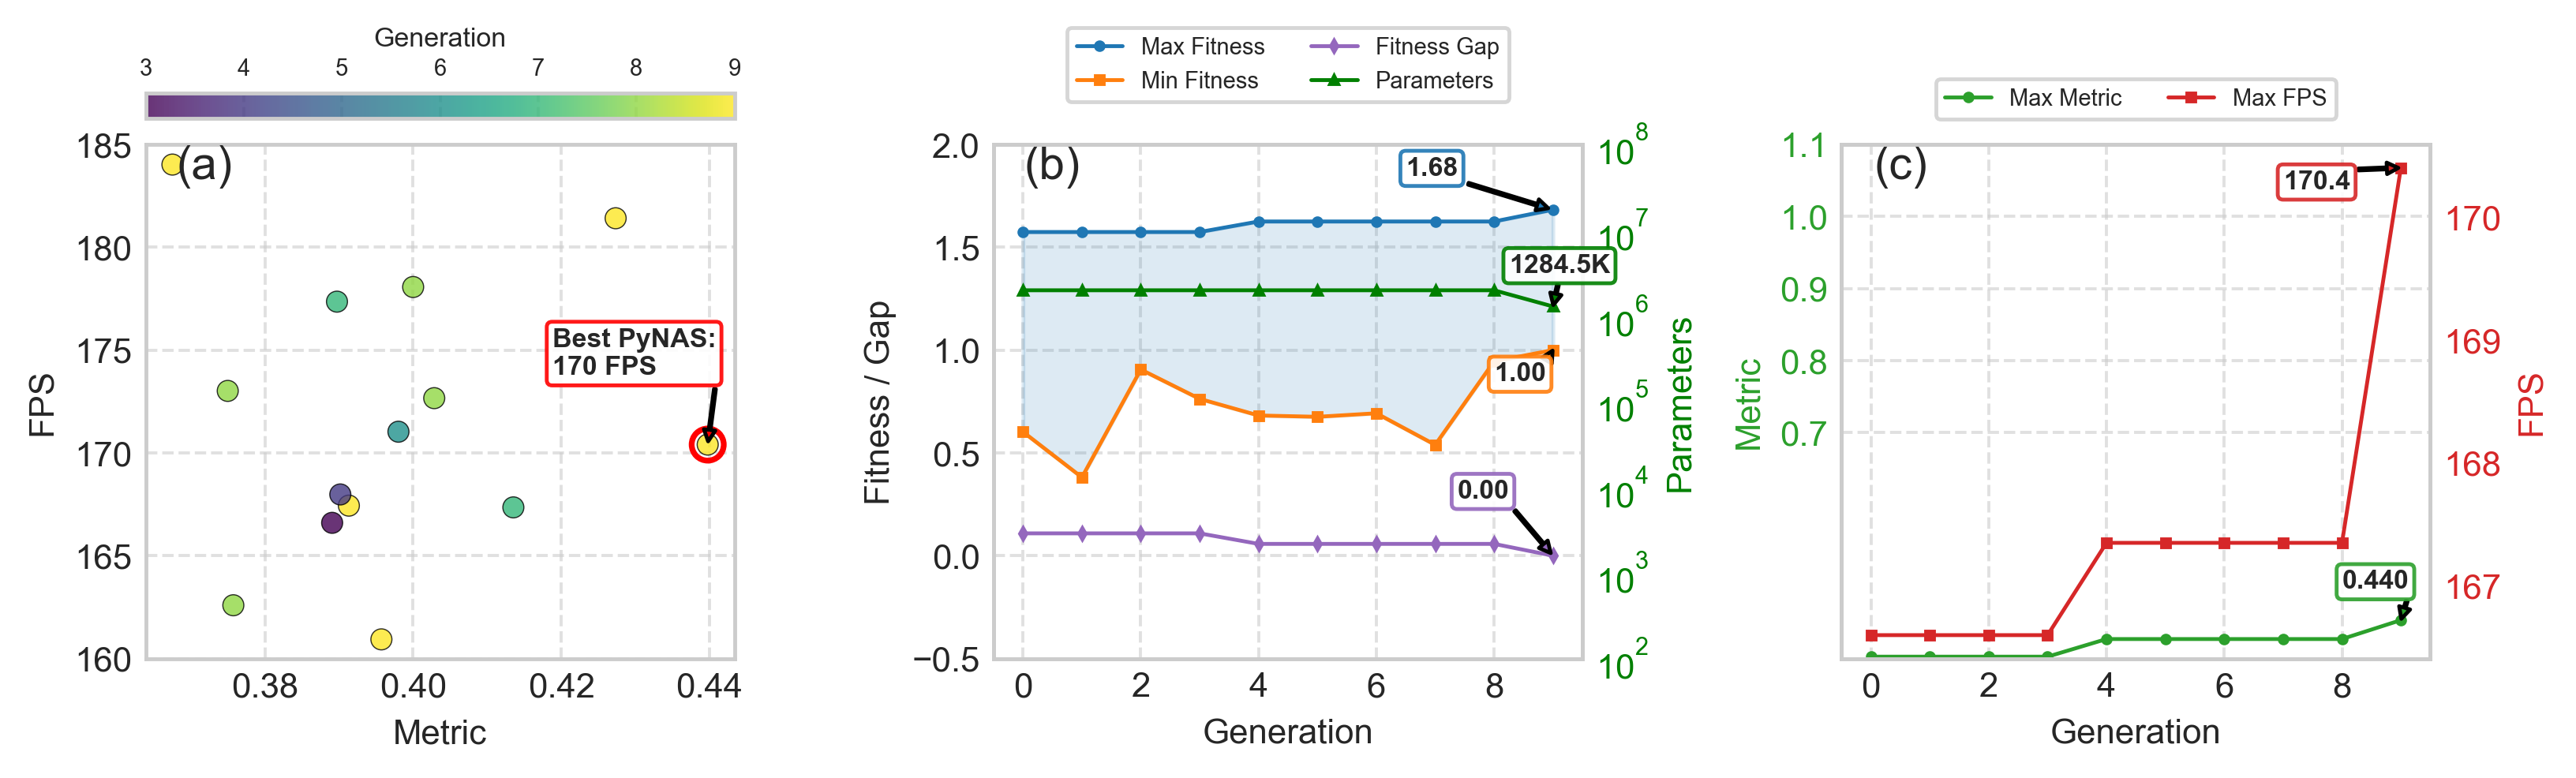

In [19]:
# SOTA comparison data (copied from print_v2.py main function for completeness in notebook)
# ---- Myriad BOARD ----
sota_data = {
    "models": ["EfficientnetB0", "Mobileone_s0", "ResNet18", "Best PyNAS"],
    "accuracies": [0.79526335, 0.683842, 0.7708845, 0.802], # Metric
    "latencies": [4.73227, 4.32405, 5.8624787, 11.5],      # FPS
    "num_params": [6253056, 8588148, 14341188, 900]
}


# ---- ORIN BOARD ----
sota_data = {
    "models": ["EfficientnetB0", "Mobileone_s0", "ResNet18", "Best PyNAS"],
    "accuracies": [0.82001495, 0.85923004, 0.8402142, 0.845], # Metric
    "latencies": [38.46798, 25.394468, 40.423565, 168],      # FPS
    "num_params": [6253056, 8588148, 14341188, 34000],        # Params
}



sota_colors = {
    "EfficientnetB0": "blue", "Mobileone_s0": "green",
    "ResNet18": "red", "Best PyNAS": "purple"
}
sota_sizes = [p / 10000 for p in sota_data["num_params"]]

if not evolution_df.empty and not top20_models.empty: # Proceed only if data processing was successful
    fig, axs = plt.subplots(1, 3, figsize=(9.5, 3), dpi=350) # Use a lower DPI like 150 for faster rendering in notebook if needed
    
    # plot_sota_comparison(axs[0], sota_data, sota_colors, sota_sizes)
    plot_pareto_front(axs[0], top20_models)
    plot_fitness_vs_generation(axs[1], evolution_df, fitness_gap)
    plot_metric_fps_vs_generation(axs[2], evolution_df)

    fig.tight_layout()
    try:
        fig.savefig(OUTPUT_FILENAME, format='pdf', dpi=500, bbox_inches='tight')
        print(f"Plot saved to {OUTPUT_FILENAME}")
        plt.show() # Display the plot in the notebook as well
    except Exception as e:
        print(f"Error saving or showing plot: {e}")
    # plt.close(fig) # Closing the figure might prevent it from showing in some notebook environments, test this.
else:
    print("Skipping plot generation as prerequisite data (evolution_df or top20_models) is missing.")

In [8]:
from print_v2 import create_evolution_animation

# Create an animation of the evolution process
# This function should be defined in print_v2.py
create_evolution_animation(
    all_dataframes=all_dataframes,
    output_filename='./outputs/evolution_animation.gif',
    interval=1000
)

No generations found. Cannot create animation.
